In [2]:
from libraries import*
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
from scipy import optimize
from scipy.optimize import curve_fit
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


In [3]:
w0 = 192.55 # larmor frequency for 11B
df = [0]*6
# Data for (-)8HQ(ipc)2B
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1]) #skipping row for frequency label
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1,2]) #skipping row for frequency label and angle = -7
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])

# Data for (+)8HQ(ipc)2B
df[3] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_X_Rot', skiprows=[1])
df[4] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Y_Rot', skiprows=[1])
df[5] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Z_Rot', skiprows=[1])




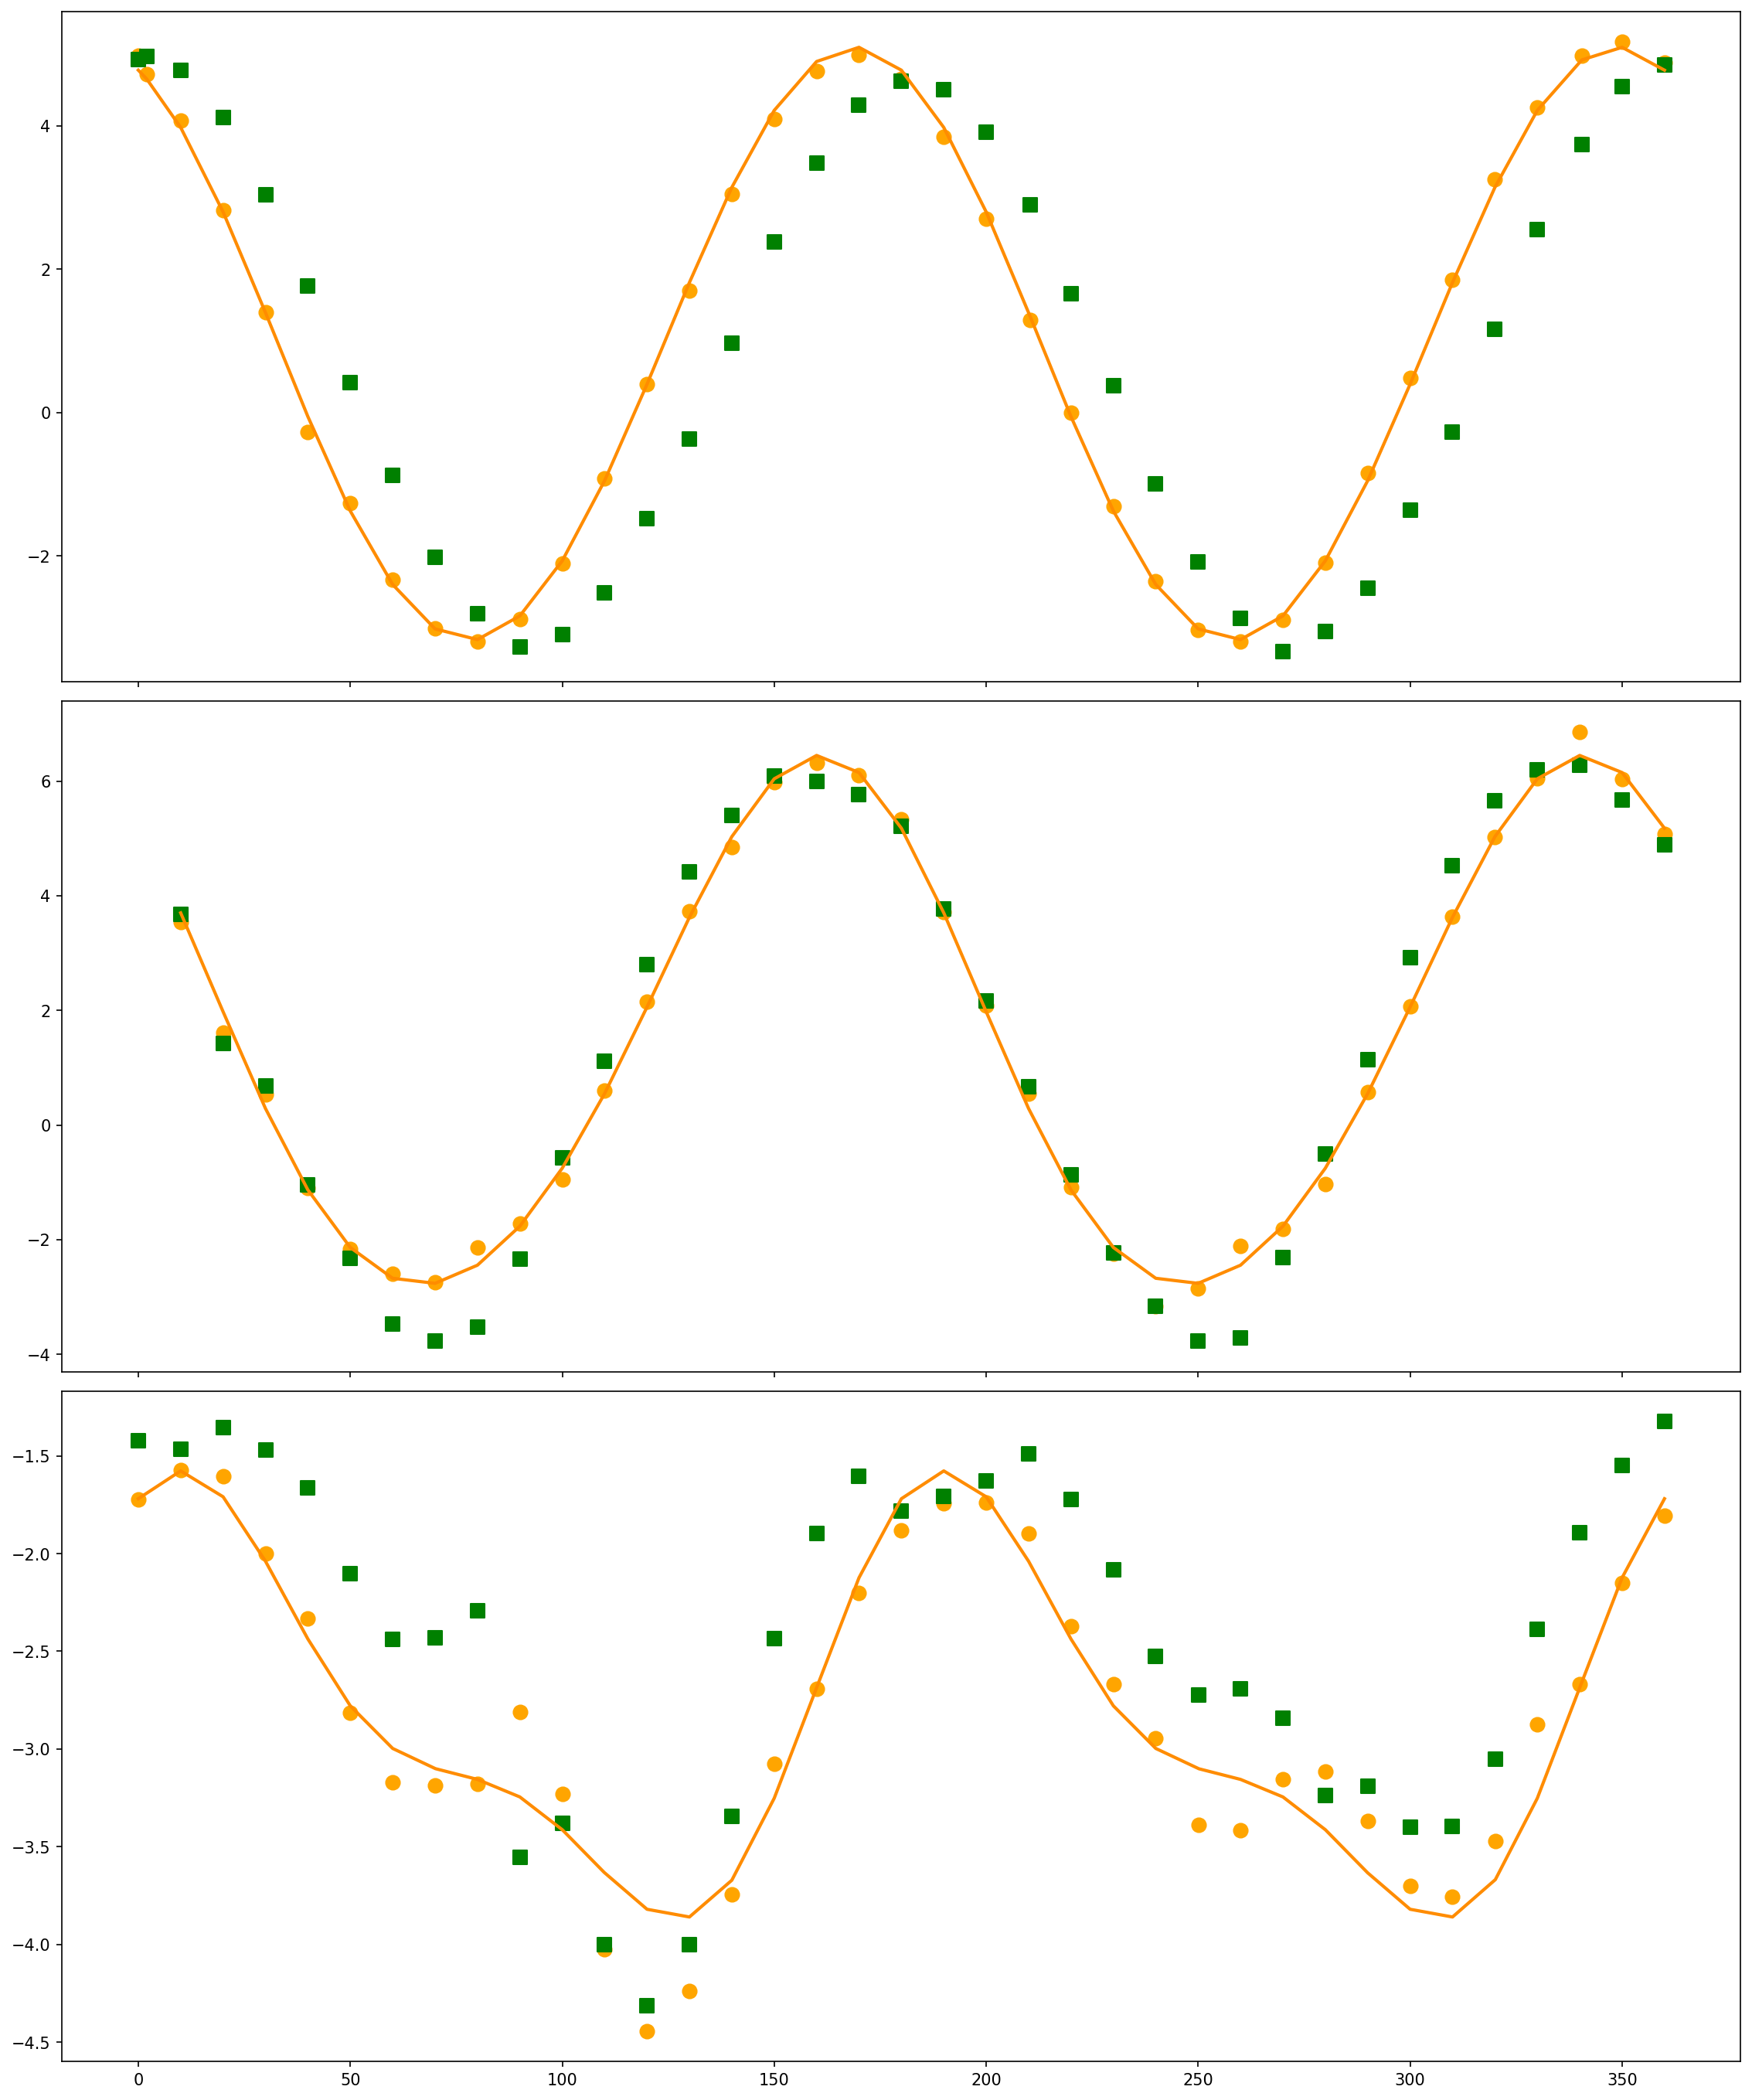

In [7]:
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
# axes[0].scatter(df[0].Angle, df[0].J_Cluster1,  marker='o', s=75, c = 'orange') #frequency in kHz

for i in range (3):
    # Fit data for both clusters
    least_squares = LeastSquares(df[i].Angle, df[i].J_Cluster1, 1, fourier5)
    
    m_s = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    
    m_s.migrad()
    
    axes[i].scatter(df[i].Angle, df[i].J_Cluster1, marker='o', s=75, c = 'orange') #frequency in kHz

    axes[i].scatter(df[i].Angle, df[i].J_Cluster2,  marker='s', s=75, c = 'green') #frequency in kHz
    
    axes[i].plot(df[i].Angle, fourier5(df[i].Angle, *m_s.values), label="fit", lw = 2, color = 'darkorange')

    # Fit curve plot
    # axes[i].plot(df[i].Angle, fourier5(df[i].Angle, *params1[:5]), label='Fit Cluster 1', color='orange')
    # axes[i].plot(df[i].Angle, fourier5(df[i].Angle, *params2[:5]), label='Fit Cluster 2', color='green')
    
    